In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os

df = pd.read_csv(os.path.join('..', 'data.csv'), index_col=0)
df

,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
id,,,,,,,,,,,,,,,,
0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3385,60,1.0,F,NO,0.0,0.0,0,0,0,261.0,123.5,79.0,29.28,70.0,103.0,0
3386,46,1.0,F,NO,0.0,0.0,0,0,0,199.0,102.0,56.0,21.96,80.0,84.0,0
3387,44,3.0,M,YES,3.0,0.0,0,1,0,352.0,164.0,119.0,28.92,73.0,72.0,1


## Dataset Overview

The dataset includes 15 features and one binary target variable (TenYearCHD). 
Features:
- Demographic:
    - age (continuous): Age of the Patient
    - education (ordinal): 1: Higher Secondary, 2: Graduate, 3: Post-graduate, 4: PhD
    - sex (nominal): 'M', 'F'
- Behavioral History:
    - is_smoking (nominal): whether or not the patient is a current smoker ('YES', 'NO')
    - cigsPerDay (continuous): number of cigarettes per day
- Past Medical History:
    - BPMeds (nominal): whether or not the patient is on blood pressure medications (0, 1)
    - prevalentStroke (nominal): whether or not the patient has had a stroke (0, 1)
    - prevalentHyp (nominal): whether or not the patient has Hypertension (0, 1)
    - diabetes (nominal): whether or not the patient has Diabetes (0, 1)
- Current Medical Data (Physical Examination, Lab Tests):
    - totChol (continuous): total cholesterol level
    - sysBP (continuous): systolic blood pressure
    - diaBP (continuous): diastolic blood pressure
    - BMI (continuous): Body Mass Index
    - heartRate (continuous)
    - glucose (continuous)

- Target variable: TenYearCHD: 10-Y outcome (1 for those who have developed CHD, 0 for those who haven't)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3390 entries, 0 to 3389
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              3390 non-null   int64  
 1   education        3303 non-null   float64
 2   sex              3390 non-null   object 
 3   is_smoking       3390 non-null   object 
 4   cigsPerDay       3368 non-null   float64
 5   BPMeds           3346 non-null   float64
 6   prevalentStroke  3390 non-null   int64  
 7   prevalentHyp     3390 non-null   int64  
 8   diabetes         3390 non-null   int64  
 9   totChol          3352 non-null   float64
 10  sysBP            3390 non-null   float64
 11  diaBP            3390 non-null   float64
 12  BMI              3376 non-null   float64
 13  heartRate        3389 non-null   float64
 14  glucose          3086 non-null   float64
 15  TenYearCHD       3390 non-null   int64  
dtypes: float64(9), int64(5), object(2)
memory usage: 450.2+ KB


As we can see there is a varying degree of missingness per features in the dataset.

### Initial Data Inspection & Cleaning

<Axes: title={'center': 'Missing Values Per Column'}>

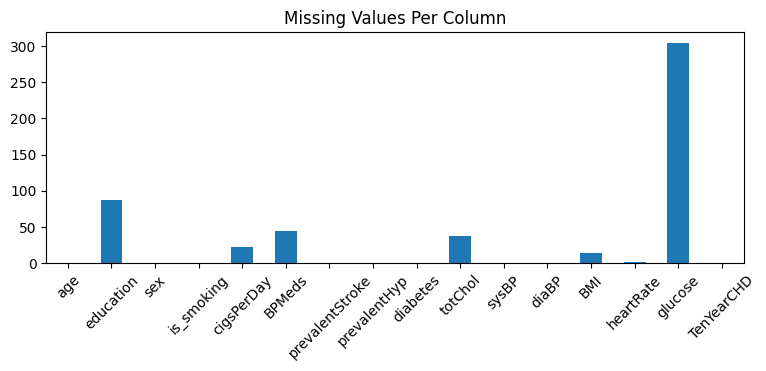

In [5]:
df.isna().sum().plot(kind='bar', figsize=(9, 3), title="Missing Values Per Column", rot=45)

In [6]:
df.shape[0], df.dropna().shape[0]

(3390, 2927)

The number of missing values is highest for `glucose` which has about 300/3390 missing cells (roughly 9%), followed by `education` which is missing roughly 100 datapoints.\
The simplest approach to address this problem would be dropping rows with any missing values (i.e. Complete Case Analysis), which we adopt, but we can later revisit this decision if needed, and perhaps utilize other methods; if it is later revealed that `glucose` has negligible predictive utility we can then discard the column instead of the rows.

In [7]:
# number of patients if we drop null values after we remove `glucose` column
df[[c for c in df.columns if c != 'glucose']].dropna().shape[0]

3189

In [8]:
df.dropna(inplace=True)

In [9]:
df.columns.to_list()

['age',
 'education',
 'sex',
 'is_smoking',
 'cigsPerDay',
 'BPMeds',
 'prevalentStroke',
 'prevalentHyp',
 'diabetes',
 'totChol',
 'sysBP',
 'diaBP',
 'BMI',
 'heartRate',
 'glucose',
 'TenYearCHD']

In [11]:
# sanity check for numerical data
columns = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
df[columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,2927.0,49.507345,8.597191,32.00,42.00,49.00,56.00,70.0
cigsPerDay,2927.0,9.112743,11.882784,0.00,0.00,0.00,20.00,70.0
totChol,2927.0,237.129142,44.613282,113.00,206.00,234.00,264.00,600.0
sysBP,2927.0,132.626409,22.326197,83.50,117.00,128.50,144.00,295.0
diaBP,2927.0,82.906218,12.078873,48.00,74.50,82.00,90.00,142.5
BMI,2927.0,25.797041,4.130376,15.96,23.03,25.38,28.04,56.8
heartRate,2927.0,75.888282,11.971207,45.00,68.00,75.00,83.00,143.0
glucose,2927.0,81.934404,24.106943,40.00,71.00,78.00,87.00,394.0


In [10]:
# sanity check for categorical data
for col in [
    'education', 'sex', 'is_smoking', 'BPMeds', 'prevalentStroke', 'prevalentHyp',
    'diabetes', 'TenYearCHD'
]:
    print(f"{col}: {df[col].unique().tolist()}")

education: [4.0, 1.0, 3.0, 2.0]
sex: ['M', 'F']
is_smoking: ['NO', 'YES']
BPMeds: [0.0, 1.0]
prevalentStroke: [0, 1]
prevalentHyp: [1, 0]
diabetes: [0, 1]
TenYearCHD: [0, 1]


There are no unexpected/sentinel values as we can see.